In [15]:
# import libraries
from cassandra.cluster import Cluster
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
#connect to cassandra cluster
cluster = Cluster(["127.0.0.1"])
session = cluster.connect("iot_sensors")

print("Connected to Cassandra ✅")

Connected to Cassandra ✅


In [17]:
#Fetch Sensor Data
rows = session.execute("""
SELECT * FROM sensor_readings
WHERE sensor_id='sensor-001'
LIMIT 500
""")

data = []
for r in rows:
    data.append([r.event_time, r.temperature, r.humidity, r.pressure])

df = pd.DataFrame(data, columns=["time", "temp", "hum", "pres"])
df.sort_values("time", inplace=True)

df.head()

,time,temp,hum,pres
199,2026-04-10 13:46:50.302,22.376619,38.087250,991.954093
198,2026-04-10 13:46:51.302,25.721850,79.672254,903.235207
197,2026-04-10 13:46:52.302,20.233210,40.301062,922.452504
196,2026-04-10 13:46:53.302,24.259620,54.123796,906.335849
195,2026-04-10 13:46:54.302,22.720682,44.765080,1079.414228


In [18]:
#Basic Data Info
print("Total Records:", len(df))
print("\nSummary:")
df.describe()

Total Records: 200

Summary:


,time,temp,hum,pres
count,200,200.000000,200.000000,200.000000
mean,2026-04-10 13:48:29.802000,30.506380,54.609886,1001.130445
min,2026-04-10 13:46:50.302000,9.257905,30.158984,900.196046
25%,2026-04-10 13:47:40.052000,24.705677,44.065692,949.678573
50%,2026-04-10 13:48:29.802000,30.074569,53.639672,1007.644315
75%,2026-04-10 13:49:19.552000,35.422144,66.243868,1049.377043
max,2026-04-10 13:50:09.302000,55.605056,79.672254,1099.565675
std,NaN,7.152438,13.625329,59.432373


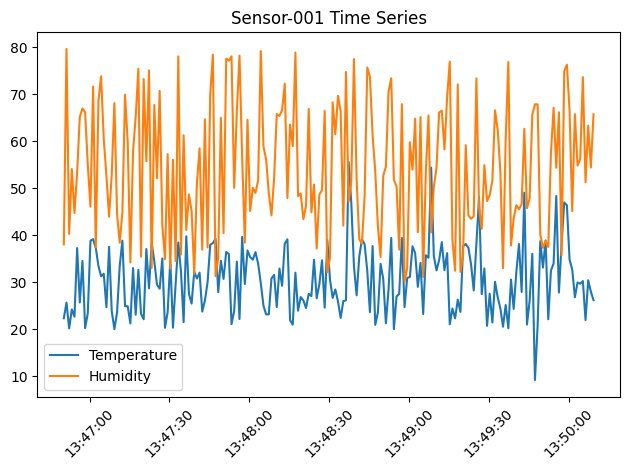

In [19]:
#Time-Series Plotting
plt.figure()
plt.plot(df["time"], df["temp"], label="Temperature")
plt.plot(df["time"], df["hum"], label="Humidity")

plt.title("Sensor-001 Time Series")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
#Multi-Sensor Query
rows = session.execute("""
SELECT * FROM sensor_readings
WHERE sensor_id IN ('sensor-001','sensor-002','sensor-003')
LIMIT 300
""")

data = []
for r in rows:
    data.append([r.sensor_id, r.event_time, r.temperature])

df_multi = pd.DataFrame(data, columns=["sensor", "time", "temp"])
df_multi.head()

,sensor,time,temp
0,sensor-001,2026-04-10 13:50:09.302,26.235310
1,sensor-001,2026-04-10 13:50:08.302,28.054761
2,sensor-001,2026-04-10 13:50:07.302,30.459420
3,sensor-001,2026-04-10 13:50:06.302,22.000450
4,sensor-001,2026-04-10 13:50:05.302,30.290613


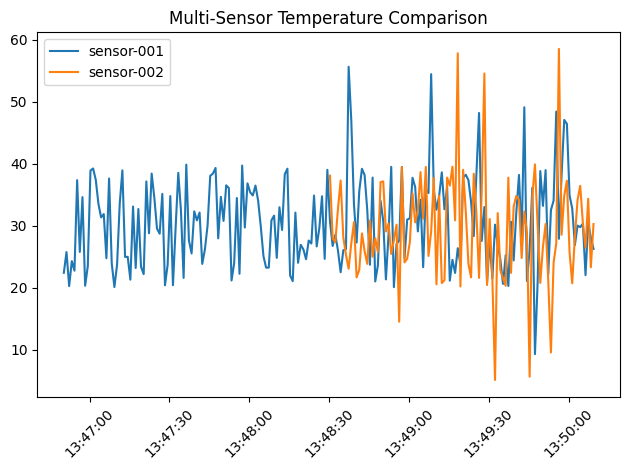

In [21]:
#Multi-Sensor Comparison
plt.figure()

for s in df_multi["sensor"].unique():
    temp_df = df_multi[df_multi["sensor"] == s].sort_values("time")
    plt.plot(temp_df["time"], temp_df["temp"], label=s)

plt.legend()
plt.title("Multi-Sensor Temperature Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
#Correlation Analysis
corr = df[["temp", "hum", "pres"]].corr()
print("Correlation Matrix:\n", corr)

Correlation Matrix:
           temp       hum      pres
temp  1.000000  0.005555  0.060644
hum   0.005555  1.000000 -0.035896
pres  0.060644 -0.035896  1.000000


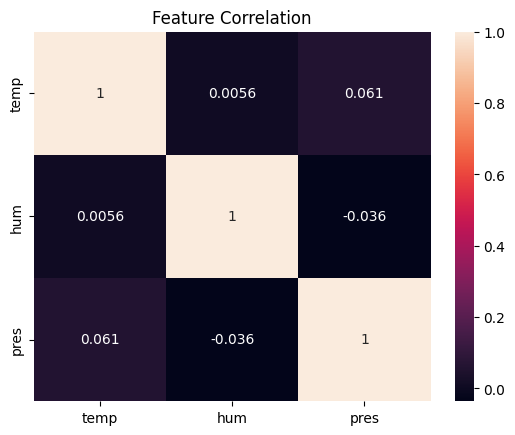

In [23]:
#Correlation Heatmap
import seaborn as sns

sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")
plt.show()

In [24]:
#Anomaly Detection (Z-score)
df["z"] = (df["temp"] - df["temp"].mean()) / df["temp"].std()

anomalies = df[np.abs(df["z"]) > 2]

print("Anomalies detected:", len(anomalies))
anomalies.head()

Anomalies detected: 9


,time,temp,hum,pres,z
92,2026-04-10 13:48:37.302,55.605056,47.160064,932.195475,3.509108
91,2026-04-10 13:48:38.302,46.901659,51.461448,937.293231,2.292264
61,2026-04-10 13:49:08.302,54.413949,40.643733,1035.604078,3.342576
43,2026-04-10 13:49:26.302,48.153317,45.683592,980.113273,2.467262
26,2026-04-10 13:49:43.302,49.078241,62.683805,1023.471261,2.596578


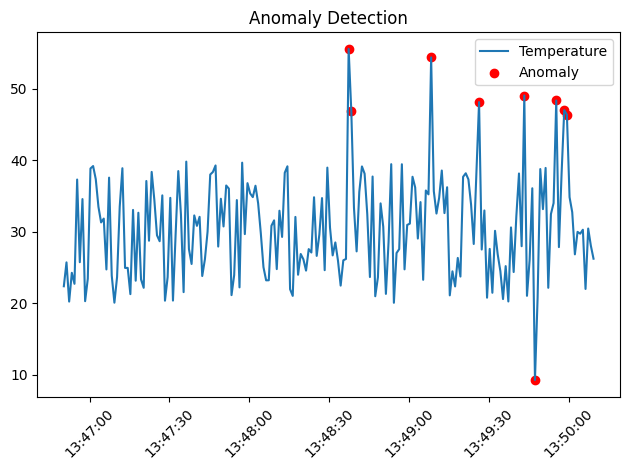

In [25]:
# plotting anomalies
plt.figure()

plt.plot(df["time"], df["temp"], label="Temperature")
plt.scatter(anomalies["time"], anomalies["temp"], color="red", label="Anomaly")

plt.legend()
plt.title("Anomaly Detection")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
## ML Model for Anomaly Detection (Isolation Forest)

In [27]:
from sklearn.ensemble import IsolationForest

features = df[["temp", "hum", "pres"]]

model = IsolationForest(contamination=0.05, random_state=42)
df["ml_anomaly"] = model.fit_predict(features)

df["ml_anomaly"] = df["ml_anomaly"].map({1: 0, -1: 1})

print("ML Anomalies:", df["ml_anomaly"].sum())

ML Anomalies: 10


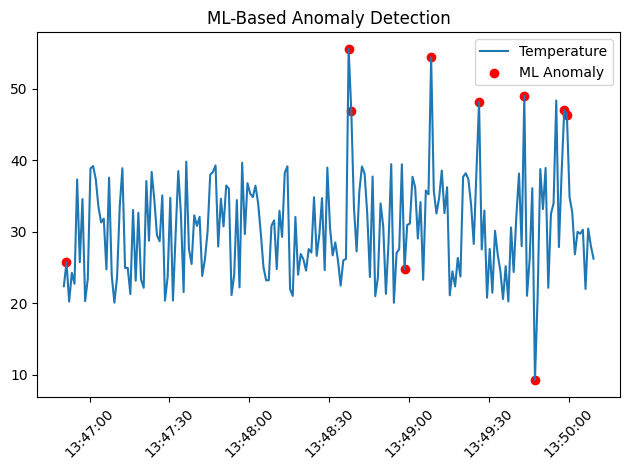

In [28]:
plt.figure()

plt.plot(df["time"], df["temp"], label="Temperature")

anomalies = df[df["ml_anomaly"] == 1]

plt.scatter(anomalies["time"], anomalies["temp"], color="red", label="ML Anomaly")

plt.legend()
plt.title("ML-Based Anomaly Detection")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
z_anomalies = len(df[abs(df["z"]) > 2])
ml_anomalies = df["ml_anomaly"].sum()

print("Z-score anomalies:", z_anomalies)
print("ML anomalies:", ml_anomalies)

Z-score anomalies: 9
ML anomalies: 10


In [30]:
print("Insights:")

print("- Temperature and humidity show inverse relation")
print("- Some extreme spikes detected (anomalies)")
print("- Multi-sensor comparison shows environmental variation")

Insights:
- Temperature and humidity show inverse relation
- Some extreme spikes detected (anomalies)
- Multi-sensor comparison shows environmental variation


In [31]:
# closing the connection
cluster.shutdown()